In [1]:
"""
Attempt with only the Prezado dataset where auggmentation is applied (4 variants per sample)
Here regression must be used since there are continuous values for the target (Biological Endpoint, that is NTSS)

"""

'\nAttempt with only the Prezado dataset where auggmentation is applied (4 variants per sample)\nHere regression must be used since there are continuous values for the target (Biological Endpoint, that is NTSS)\n\n'

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [3]:
from src.utils.io import load_excel

DATA_DIR = PROJECT_ROOT / "data"

train = load_excel(
    DATA_DIR /
    "processed" /
    "processed_elec-prot" /
    "prezado_only.xlsx"
)

In [4]:
features = ["MDR", "PW", "Frequency", "NoP", "TD", "Particle", "Target"]

X= train[features]
y = train["Endpoint"]

titles = train["Title"]

In [5]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor
import numpy as np

gkf = GroupKFold(n_splits=5)

model = XGBRegressor(
    n_estimators=600,
    max_depth=3,
    learning_rate=0.04,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=2.0,
    random_state=4,
    objective="reg:squarederror"
)

mae_scores = []
test = []
pred = []

for train_idx, test_idx in gkf.split(X, y, groups=titles):
    model.fit(X.iloc[train_idx], y.iloc[train_idx])
    y_test = y.iloc[test_idx]
    y_preds = model.predict(X.iloc[test_idx])
    mae_scores.append(mean_absolute_error(y_test, y_preds))
    test.extend(y_test)
    pred.extend(y_preds)

test = np.array(test)
pred = np.array(pred)

print("MAE medio:", np.mean(mae_scores))


MAE medio: 0.5765544403482367


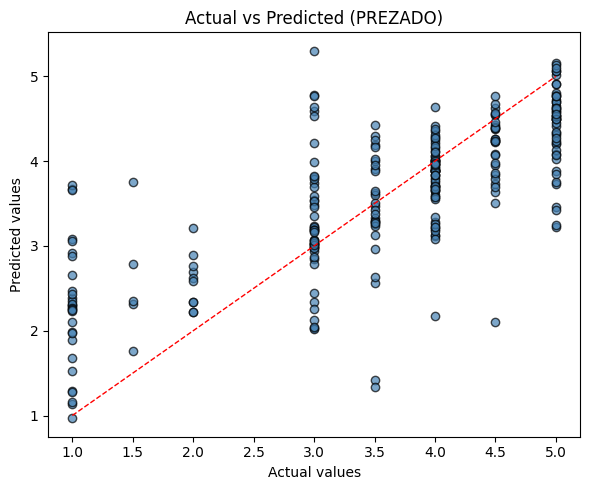

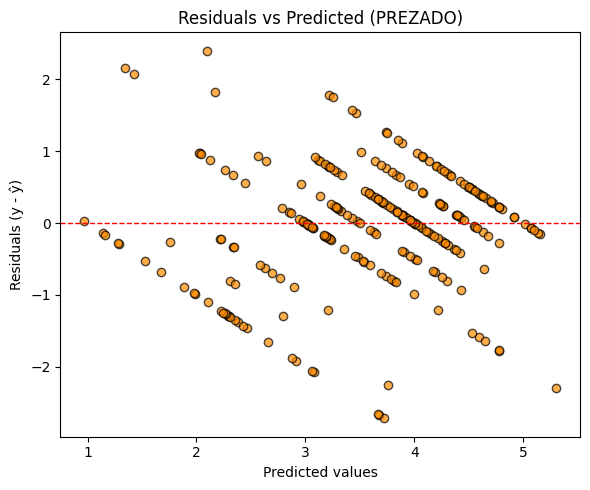

In [6]:
import matplotlib.pyplot as plt

# --- PLOT 1: ACTUAL vs PREDICTED ---
plt.figure(figsize=(6, 5))
plt.scatter(test, pred, alpha=0.7, color="steelblue", edgecolor="k")
plt.plot([test.min(), test.max()],
         [test.min(), test.max()],
         "r--", linewidth=1)
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Actual vs Predicted (PREZADO)")
plt.tight_layout()
plt.show()

residuals = test - pred
# --- PLOT 2: RESIDUALS vs PREDICTED ---
plt.figure(figsize=(6, 5))
plt.scatter(pred, residuals, alpha=0.7, color="darkorange", edgecolor="k")
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.xlabel("Predicted values")
plt.ylabel("Residuals (y - ŷ)")
plt.title("Residuals vs Predicted (PREZADO)")
plt.tight_layout()
plt.show()




,feature,importance_mean,importance_std
4,TD,0.659666,0.111277
6,Target,0.319479,0.026311
2,Frequency,0.245940,0.080202
0,MDR,0.218632,0.102764
5,Particle,0.087184,0.027810
3,NoP,0.031466,0.019912
1,PW,0.029173,0.021514


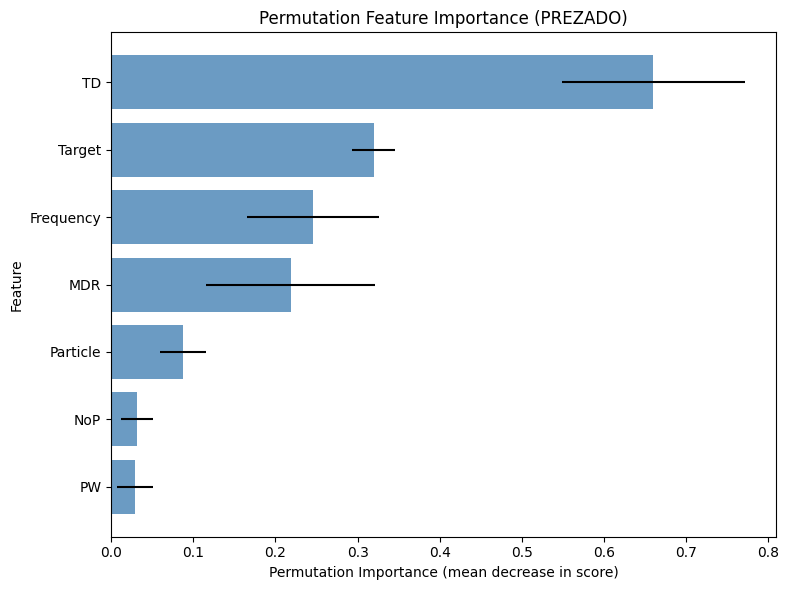

In [7]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

# --- COLLECT PERMUTATION IMPORTANCE ACROSS FOLDS ---
all_importances = []

gkf = GroupKFold(n_splits=5)

for train_idx, test_idx in gkf.split(X, y, groups=titles):
    model.fit(X.iloc[train_idx], y.iloc[train_idx])

    result = permutation_importance(
        model,
        X.iloc[test_idx],
        y.iloc[test_idx],
        n_repeats=30,
        random_state=48
    )

    all_importances.append(result.importances_mean)

# --- AVERAGE IMPORTANCES ---
mean_importance = np.mean(all_importances, axis=0)
std_importance = np.std(all_importances, axis=0)

df_imp = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": mean_importance,
    "importance_std": std_importance
}).sort_values("importance_mean", ascending=False)

display(df_imp)

# --- PLOT FEATURE IMPORTANCE ---
plt.figure(figsize=(8, 6))
plt.barh(
    df_imp["feature"],
    df_imp["importance_mean"],
    xerr=df_imp["importance_std"],
    color="steelblue",
    alpha=0.8
)
plt.gca().invert_yaxis()
plt.xlabel("Permutation Importance (mean decrease in score)")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance (PREZADO)")
plt.tight_layout()
plt.show()


C:\Users\silvi\AppData\Local\Temp\ipykernel_3492\2053184995.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.mean(np.abs(g["y_true"] - g["y_pred"])))


,y_true,MAE
0,1.0,1.274354
1,1.5,1.093346
2,2.0,0.587745
3,3.0,0.558201
4,3.5,0.505604
5,4.0,0.314525
6,4.5,0.419233
7,5.0,0.599912


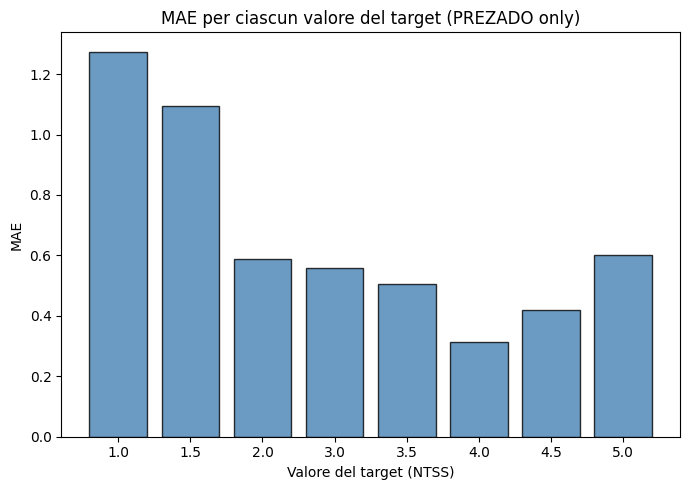

In [8]:
import pandas as pd
import numpy as np

df_eval = pd.DataFrame({
    "y_true": test,
    "y_pred": pred
})

# Calcolo MAE per ogni valore unico del target
mae_per_target = (
    df_eval
    .groupby("y_true")
    .apply(lambda g: np.mean(np.abs(g["y_true"] - g["y_pred"])))
    .reset_index(name="MAE")
)

display(mae_per_target)

# Grafico
plt.figure(figsize=(7, 5))
plt.bar(mae_per_target["y_true"].astype(str), mae_per_target["MAE"],
        color="steelblue", edgecolor="black", alpha=0.8)
plt.xlabel("Valore del target (NTSS)")
plt.ylabel("MAE")
plt.title("MAE per ciascun valore del target (PREZADO only)")
plt.tight_layout()
plt.show()
